In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.optimizers import SGD

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(128, activation='relu'))
model.add(Dense(56, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 56)             │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,945 (159.94 KB)

 Trainable params: 40,945 (159.94 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
sgd = SGD(momentum=0.9, nesterov=True)

model.compile(loss = 'binary_crossentropy' , optimizer= sgd , metrics= ['accuracy'])

In [5]:
from keras.callbacks import EarlyStopping
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=50,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [6]:
history = model.fit(df.iloc[: , 0:2].values , df.iloc[: , -1].values,  validation_split= 0.2 , epochs= 200, callbacks= callback , verbose= False)

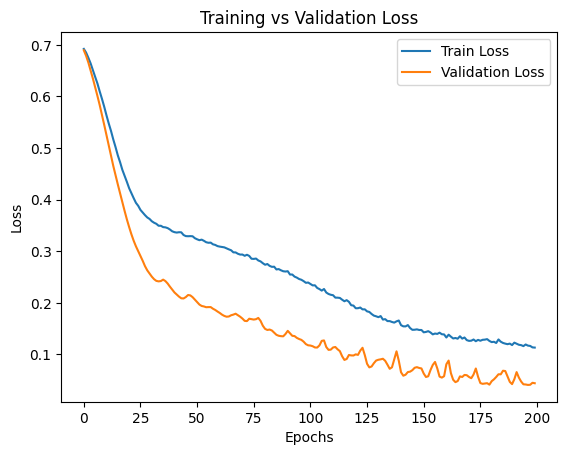

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

NAG provides more stable and efficient optimization than vanilla momentum in this setup.